In [4]:
import sys
import os

sys.path.append(
    os.path.abspath("..")
)


In [5]:
!pip install shap

In [15]:
import importlib
import src.feature_extraction.html_features as html_features
import src.feature_extraction.whois_features as whois_features
import src.prediction.predictor as predictor
import explainability.shap_explainer as shap_explainer
importlib.reload(html_features)
importlib.reload(whois_features)
importlib.reload(predictor)
importlib.reload(shap_explainer)


c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


<module 'explainability.shap_explainer' from 'c:\\Users\\Dell\\OneDrive\\Desktop\\Phishing_url_detector\\explainability\\shap_explainer.py'>

In [16]:

from src.feature_extraction.url_features import extract_url_features

urls = [
    "https://google.com",
    "https://paypal-security-login123.com/verify/account",
    "https://chatgpt.com"
]

for url in urls:
    print("\nURL:", url)
    print(extract_url_features(url))


URL: https://google.com
{'length_url': 18, 'ratio_digits_url': 0.0, 'length_words_raw': 3, 'longest_words_raw': 6, 'length_hostname': 10, 'avg_word_path': 0, 'char_repeat': 3}

URL: https://paypal-security-login123.com/verify/account
{'length_url': 51, 'ratio_digits_url': 0.058823529411764705, 'length_words_raw': 7, 'longest_words_raw': 8, 'length_hostname': 28, 'avg_word_path': 6.5, 'char_repeat': 3}

URL: https://chatgpt.com
{'length_url': 19, 'ratio_digits_url': 0.0, 'length_words_raw': 3, 'longest_words_raw': 7, 'length_hostname': 11, 'avg_word_path': 0, 'char_repeat': 2}


In [17]:
from src.feature_extraction.html_features import extract_html_features

url = "https://google.com"
features=extract_html_features(url)
print(features)



{'phish_hints': 0, 'ratio_extHyperlinks': 0.0, 'ratio_intHyperlinks': 1.0, 'safe_anchor': 0.0, 'ratio_extRedirection': 0.0, 'domain_in_title': 1}


In [18]:
from src.feature_extraction.whois_features import extract_domain_age

print(extract_domain_age("google.com"))

10555


In [19]:
import sys
!{sys.executable} -m pip install python-whois

In [20]:
from src.feature_extraction.feature_pipeline import extract_features

url="https://github.com"

features=extract_features(url)

print(features)

{'length_url': 18, 'ratio_digits_url': 0.0, 'length_words_raw': 3, 'longest_words_raw': 6, 'length_hostname': 10, 'avg_word_path': 0, 'char_repeat': 2, 'phish_hints': 0, 'ratio_extHyperlinks': 0.09154929577464789, 'ratio_intHyperlinks': 0.8732394366197183, 'safe_anchor': 1.4084507042253522, 'ratio_extRedirection': 0, 'domain_in_title': 1, 'domain_age': 6878}


In [21]:
from src.prediction.predictor import predict_url

urls = [
    
    "https://google.com",
    "https://github.com",
    "https://chatgpt.com",
    "https://openai.com",
    "https://microsoft.com",
    "https://amazon.com",
    "https://wikipedia.org",
    "https://linkedin.com",
    "https://paypal.com",
    "https://stackoverflow.com",

    
    
    "https://google-account-recovery-update.com/signin",
    "https://amazon-secure-payment-alert.com/login",
    "https://microsoft-security-center-verify.net/account",
    "https://facebook-login-confirmation.com/verify",
    "https://apple-id-security-check.com/login",
    "https://bank-verification-alert-secure.com/auth",
    "https://netflix-payment-update-now.com/billing",
    "https://instagram-blue-tick-verification.com/verify",
    "https://dhl-package-tracking-update.com/track"
]
for url in urls:
    result=predict_url(url)
    print(result)


{'prediction': 'Legitimate', 'confidence': np.float64(0.7440000000000001), 'features': {'length_url': 18, 'ratio_digits_url': 0.0, 'length_words_raw': 3, 'longest_words_raw': 6, 'length_hostname': 10, 'avg_word_path': 0, 'char_repeat': 3, 'phish_hints': 0, 'ratio_extHyperlinks': 0.0, 'ratio_intHyperlinks': 1.0, 'safe_anchor': 0.0, 'ratio_extRedirection': 0.0, 'domain_in_title': 1, 'domain_age': 10555}}
{'prediction': 'Legitimate', 'confidence': np.float64(0.6755952380952381), 'features': {'length_url': 18, 'ratio_digits_url': 0.0, 'length_words_raw': 3, 'longest_words_raw': 6, 'length_hostname': 10, 'avg_word_path': 0, 'char_repeat': 2, 'phish_hints': 0, 'ratio_extHyperlinks': 0.09154929577464789, 'ratio_intHyperlinks': 0.8732394366197183, 'safe_anchor': 1.4084507042253522, 'ratio_extRedirection': 0, 'domain_in_title': 1, 'domain_age': 6878}}
'NoneType' object has no attribute 'text'
{'prediction': 'Phishing', 'confidence': np.float64(0.6375), 'features': {'length_url': 19, 'ratio_digi

Error trying to connect to socket: closing socket - timed out


{'prediction': 'Legitimate', 'confidence': np.float64(0.6313333333333333), 'features': {'length_url': 25, 'ratio_digits_url': 0.0, 'length_words_raw': 3, 'longest_words_raw': 13, 'length_hostname': 17, 'avg_word_path': 0, 'char_repeat': 2, 'phish_hints': 0, 'ratio_extHyperlinks': 0, 'ratio_intHyperlinks': 0, 'safe_anchor': 0, 'ratio_extRedirection': 0.0, 'domain_in_title': 0, 'domain_age': 8261}}
{'prediction': 'Phishing', 'confidence': np.float64(0.7544047619047619), 'features': {'length_url': 49, 'ratio_digits_url': 0.0, 'length_words_raw': 7, 'longest_words_raw': 8, 'length_hostname': 34, 'avg_word_path': 6.0, 'char_repeat': 4, 'phish_hints': 0, 'ratio_extHyperlinks': 0, 'ratio_intHyperlinks': 0, 'safe_anchor': 0, 'ratio_extRedirection': 0, 'domain_in_title': 0, 'domain_age': 0}}
{'prediction': 'Phishing', 'confidence': np.float64(0.8481666666666666), 'features': {'length_url': 45, 'ratio_digits_url': 0.0, 'length_words_raw': 7, 'longest_words_raw': 7, 'length_hostname': 31, 'avg_wo

In [9]:
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

.\random_forest_phishing.pkl


In [10]:
import shap


'NoneType' object has no attribute 'text'
<class 'shap._explanation.Explanation'>
(1, 14, 2)


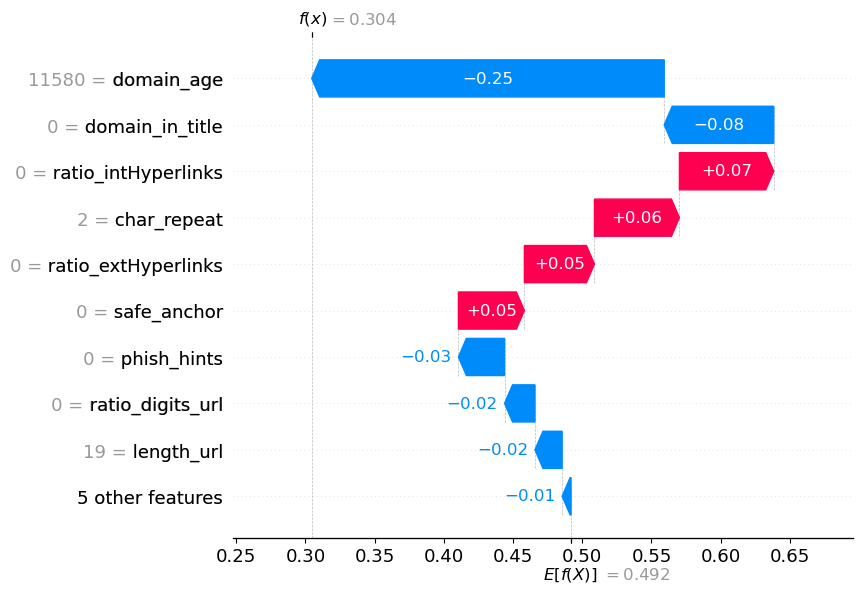

'NoneType' object has no attribute 'text'
{'prediction': 'Legitimate', 'confidence': np.float64(0.6955000000000001)}


In [12]:
from explainability.shap_explainer import explain_url
url="https://amazon.com/"

shap_values, X, explainer = explain_url(url)
print(type(shap_values))
print(shap_values.shape)

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0,:,1],
        base_values=explainer.expected_value[1],
        data=X.iloc[0],
        feature_names=X.columns
    )
)
result=predict_url(url)
print(result)
